# Imports

In [1]:
import os
import json
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd

In [3]:
from alphalens.tears import create_summary_tear_sheet
from alphalens.utils import get_clean_factor_and_forward_returns

In [4]:
data_store=Path("./Prepared_Data_Store")

# Loading Stocks's Trade Price Data

## Traded Tickers

In [5]:
with open(os.path.join(data_store,"stocks_to_traded.json"),"r") as file:
    traded_tickers=json.load(file)

## Duration of Data

In [6]:
start_date=2009
end_date=2018

In [7]:
idx=pd.IndexSlice

In [8]:
data=pd.read_csv(
    "./Data_Store/wiki_prices.csv",
    parse_dates=["date"],
    index_col=["date","ticker"]
)

In [9]:
data=data.sort_index()

In [10]:
data=data.loc[idx[str(start_date):str(end_date),traded_tickers],"adj_open"]

In [11]:
data=data.swaplevel()
data.index.names=["ticker","date"]

In [12]:
trade_prices=(data
              .shift(-1)
              .unstack("ticker")
              .sort_index()
              .tz_localize("UTC",level="date")
              .ffill()
     )

In [13]:
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2323 entries, 2009-01-02 00:00:00+00:00 to 2018-03-27 00:00:00+00:00
Columns: 374 entries, A to FTNT
dtypes: float64(374)
memory usage: 6.6 MB


# Loading Factor's Data

In [14]:
factor_data=pd.read_csv(
    os.path.join(data_store,"factors.csv"),
    parse_dates=["date"],
    index_col=["date","ticker"]
)

In [15]:
factor_data=(factor_data
             .sort_index()
             .tz_localize("UTC",level="date"))

In [16]:
factor_data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00+0000', tz='UTC'), 'A') to (Timestamp('2017-11-29 00:00:00+0000', tz='UTC'), 'ZBRA')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Model1_Factors   732292 non-null  float64
 1   Model4_Factors   732292 non-null  float64
 2   Model2_Factors   732292 non-null  float64
 3   Model3_Factors   732292 non-null  float64
 4   Model8_Factors   732292 non-null  float64
 5   Combined_Factor  732292 non-null  float64
dtypes: float64(6)
memory usage: 36.4+ MB


# Evaluating Signals

In [17]:
quantiles=5
periods=(1,5,7,15,21)

## Model-1

### Factors

In [18]:
model1_factors=factor_data["Model1_Factors"]

In [19]:
model1_factors.info()

<class 'pandas.core.series.Series'>
MultiIndex: 732292 entries, (Timestamp('2010-02-22 00:00:00+0000', tz='UTC'), 'A') to (Timestamp('2017-11-29 00:00:00+0000', tz='UTC'), 'ZBRA')
Series name: Model1_Factors
Non-Null Count   Dtype  
--------------   -----  
732292 non-null  float64
dtypes: float64(1)
memory usage: 8.5+ MB


## Summary Tear Sheet

In [20]:
df=get_clean_factor_and_forward_returns(
    factor=model1_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.347578,0.014616,-0.011717,0.008165,146850,20.053558
2,-0.038311,0.018497,-0.006119,0.004907,146847,20.053148
3,-0.031985,0.022701,-0.003461,0.004640,144895,19.786587
4,-0.026832,0.027229,-0.000853,0.004511,146847,20.053148
5,-0.019864,0.207722,0.004333,0.006340,146850,20.053558


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.004,-0.002,-0.001,-0.000,-0.000
beta,0.000,0.002,0.008,0.003,-0.000
Mean Period Wise Return Top Quantile (bps),0.032,-0.052,-0.032,-0.013,-0.004
Mean Period Wise Return Bottom Quantile (bps),0.150,0.051,0.023,0.016,0.005
Mean Period Wise Spread (bps),-0.118,-0.102,-0.056,-0.029,-0.010


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.000,-0.003,-0.003,-0.004,-0.002
IC Std.,0.052,0.050,0.050,0.051,0.052
Risk-Adjusted IC,-0.006,-0.065,-0.062,-0.074,-0.046
t-stat(IC),-0.278,-2.897,-2.749,-3.285,-2.043
p-value(IC),0.781,0.004,0.006,0.001,0.041
IC Skew,0.037,-0.010,0.005,-0.016,-0.018
IC Kurtosis,-0.061,-0.189,-0.196,0.120,0.009


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.582,0.707,0.701,0.769,0.744
Quantile 2 Mean Turnover,0.739,0.776,0.778,0.790,0.786
Quantile 3 Mean Turnover,0.759,0.780,0.782,0.788,0.790
Quantile 4 Mean Turnover,0.738,0.773,0.770,0.789,0.785
Quantile 5 Mean Turnover,0.572,0.732,0.737,0.775,0.753


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.411,0.131,0.136,0.025,0.089


<Figure size 640x480 with 0 Axes>

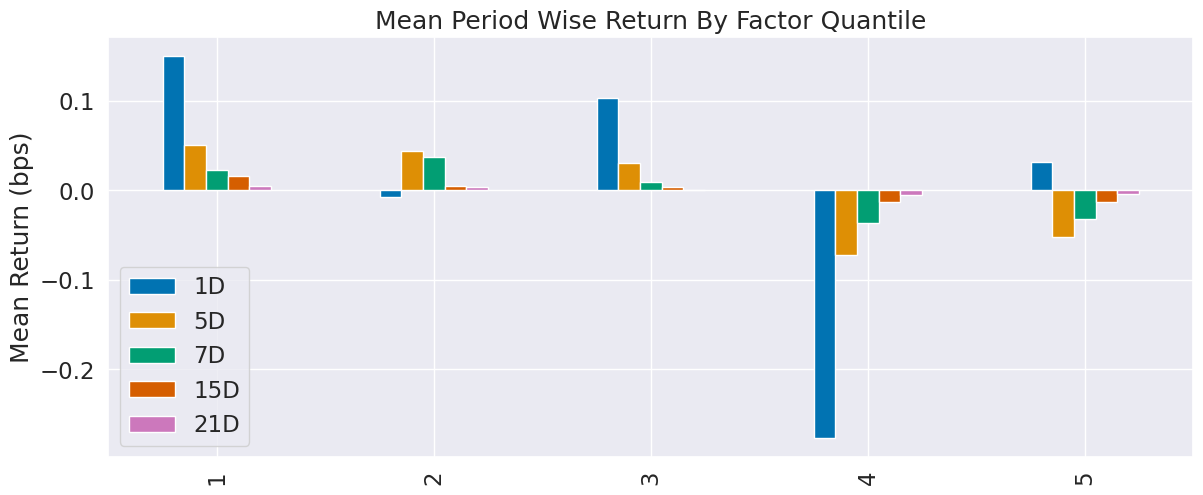

In [21]:
create_summary_tear_sheet(df)

## Model-4

### Factors

In [22]:
model4_factors=factor_data["Model4_Factors"]

### Summary Tear Sheet

In [23]:
df=get_clean_factor_and_forward_returns(
    factor=model4_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.342686,0.014296,-0.009353,0.007220,146850,20.053558
2,-0.037164,0.018623,-0.004046,0.004133,146847,20.053148
3,-0.030385,0.021763,-0.001626,0.003858,144895,19.786587
4,-0.025245,0.026192,0.000683,0.003730,146847,20.053148
5,-0.018643,0.184415,0.005131,0.005298,146850,20.053558


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.003,-0.002,-0.001,-0.000,-0.000
beta,0.002,0.005,0.010,0.012,0.008
Mean Period Wise Return Top Quantile (bps),-0.044,-0.046,-0.028,-0.011,-0.004
Mean Period Wise Return Bottom Quantile (bps),0.030,0.077,0.053,0.015,0.005
Mean Period Wise Spread (bps),-0.074,-0.123,-0.081,-0.026,-0.008


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.001,-0.003,-0.003,-0.004,-0.003
IC Std.,0.052,0.050,0.050,0.050,0.052
Risk-Adjusted IC,-0.014,-0.064,-0.069,-0.081,-0.053
t-stat(IC),-0.608,-2.830,-3.036,-3.591,-2.362
p-value(IC),0.544,0.005,0.002,0.000,0.018
IC Skew,0.018,0.007,-0.014,-0.027,-0.063
IC Kurtosis,-0.137,-0.145,-0.134,0.022,-0.012


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.590,0.710,0.709,0.787,0.767
Quantile 2 Mean Turnover,0.745,0.779,0.780,0.795,0.792
Quantile 3 Mean Turnover,0.761,0.781,0.782,0.788,0.793
Quantile 4 Mean Turnover,0.743,0.773,0.772,0.790,0.787
Quantile 5 Mean Turnover,0.601,0.738,0.746,0.799,0.773


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.376,0.12,0.118,-0.021,0.042


<Figure size 640x480 with 0 Axes>

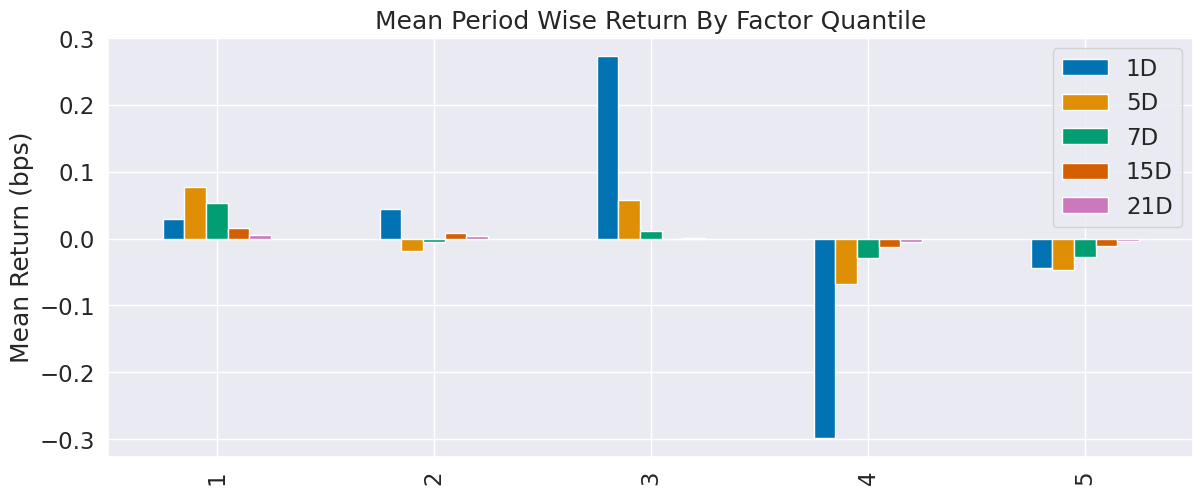

In [24]:
create_summary_tear_sheet(df)

## Model-2

### Factors

In [25]:
model2_factors=factor_data["Model2_Factors"]

### Summary Tear Sheet

In [26]:
df=get_clean_factor_and_forward_returns(
    factor=model2_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.352665,0.012562,-0.011568,0.008056,146850,20.053558
2,-0.038076,0.016463,-0.006066,0.004812,146847,20.053148
3,-0.032070,0.020107,-0.003468,0.004547,144895,19.786587
4,-0.026153,0.025183,-0.000928,0.004413,146847,20.053148
5,-0.019703,0.208656,0.004130,0.006216,146850,20.053558


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.005,-0.002,-0.001,-0.000,-0.000
beta,-0.000,0.002,0.007,0.003,-0.000
Mean Period Wise Return Top Quantile (bps),-0.115,-0.059,-0.030,-0.011,-0.004
Mean Period Wise Return Bottom Quantile (bps),0.298,0.054,0.033,0.015,0.006
Mean Period Wise Spread (bps),-0.413,-0.112,-0.063,-0.025,-0.010


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.000,-0.003,-0.003,-0.003,-0.002
IC Std.,0.051,0.050,0.050,0.051,0.052
Risk-Adjusted IC,-0.003,-0.056,-0.053,-0.067,-0.043
t-stat(IC),-0.153,-2.476,-2.336,-2.967,-1.904
p-value(IC),0.879,0.013,0.020,0.003,0.057
IC Skew,0.035,-0.052,-0.015,-0.022,-0.009
IC Kurtosis,-0.103,-0.196,-0.183,0.088,0.020


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.582,0.705,0.699,0.769,0.741
Quantile 2 Mean Turnover,0.737,0.774,0.776,0.790,0.786
Quantile 3 Mean Turnover,0.759,0.780,0.781,0.788,0.789
Quantile 4 Mean Turnover,0.737,0.771,0.769,0.788,0.785
Quantile 5 Mean Turnover,0.573,0.725,0.735,0.770,0.745


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.41,0.14,0.142,0.033,0.101


<Figure size 640x480 with 0 Axes>

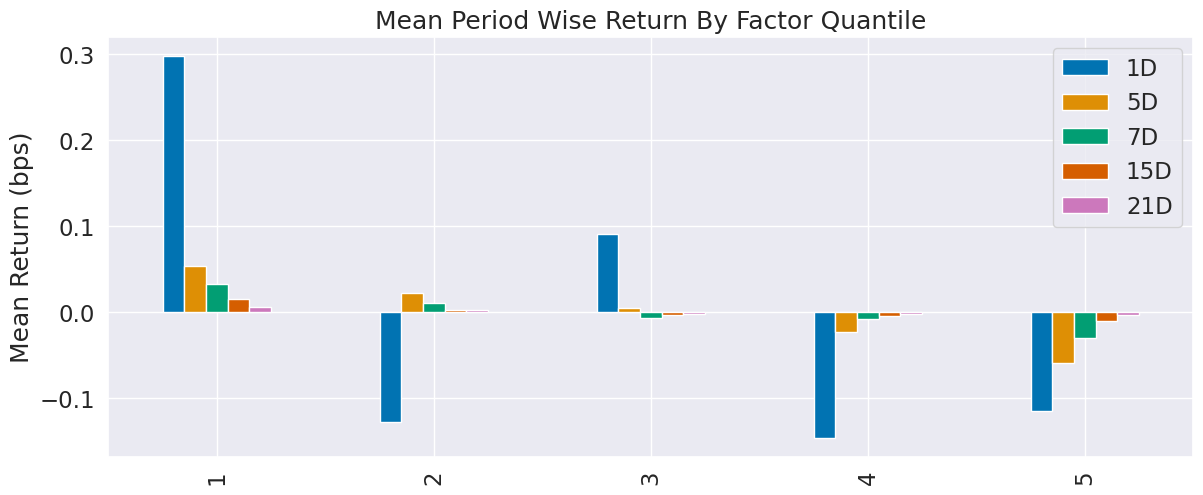

In [27]:
create_summary_tear_sheet(df)

## Model-3

### Factors

In [28]:
model3_factors=factor_data["Model3_Factors"]

### Summary Tear Sheet

In [29]:
df=get_clean_factor_and_forward_returns(
    factor=model3_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.370912,0.011176,-0.010485,0.007909,146850,20.053558
2,-0.025838,0.015405,-0.005557,0.003876,146847,20.053148
3,-0.020282,0.019604,-0.003314,0.003610,144895,19.786587
4,-0.016397,0.026352,-0.001137,0.003487,146847,20.053148
5,-0.012854,0.221522,0.003437,0.006283,146850,20.053558


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.012,-0.002,-0.001,-0.000,-0.000
beta,0.000,0.003,0.008,-0.002,-0.007
Mean Period Wise Return Top Quantile (bps),-0.634,-0.111,-0.068,-0.023,-0.011
Mean Period Wise Return Bottom Quantile (bps),0.259,0.029,0.008,0.005,0.002
Mean Period Wise Spread (bps),-0.893,-0.141,-0.076,-0.029,-0.013


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.001,-0.003,-0.003,-0.004,-0.003
IC Std.,0.051,0.051,0.052,0.052,0.053
Risk-Adjusted IC,-0.012,-0.066,-0.057,-0.077,-0.050
t-stat(IC),-0.526,-2.915,-2.510,-3.422,-2.232
p-value(IC),0.599,0.004,0.012,0.001,0.026
IC Skew,-0.034,-0.075,-0.095,-0.044,0.031
IC Kurtosis,-0.097,-0.130,-0.120,0.000,0.001


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.481,0.683,0.710,0.775,0.735
Quantile 2 Mean Turnover,0.694,0.766,0.774,0.795,0.788
Quantile 3 Mean Turnover,0.724,0.774,0.778,0.790,0.791
Quantile 4 Mean Turnover,0.690,0.761,0.767,0.788,0.782
Quantile 5 Mean Turnover,0.475,0.713,0.742,0.805,0.767


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.575,0.172,0.116,-0.02,0.079


<Figure size 640x480 with 0 Axes>

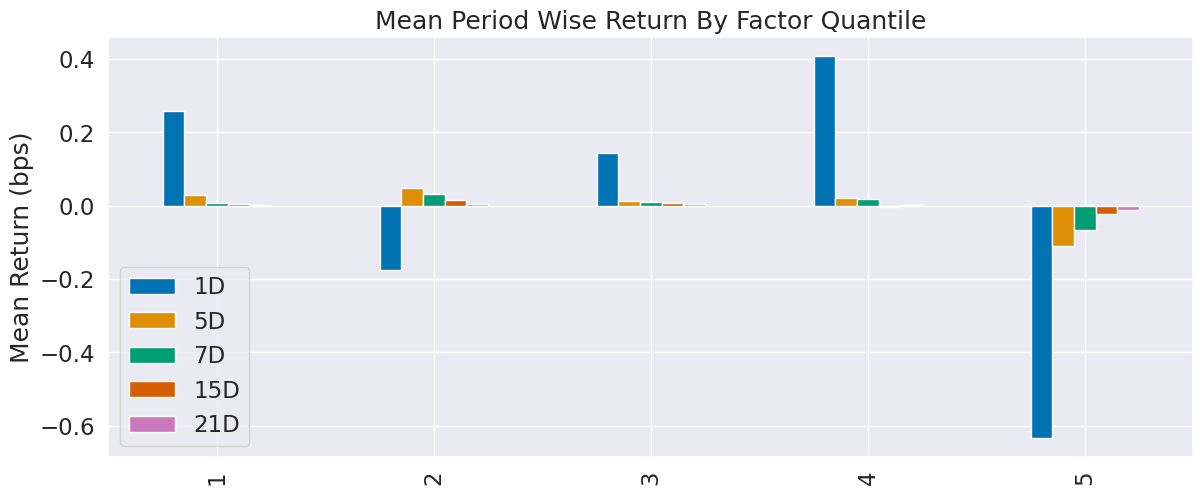

In [30]:
create_summary_tear_sheet(df)

## Model-8

### Factors

In [31]:
model8_factors=factor_data["Model8_Factors"]

### Summary Tear Sheet

In [32]:
df=get_clean_factor_and_forward_returns(
    factor=model8_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.904161,0.014045,-0.009934,0.008566,146850,20.053558
2,-0.095480,0.017725,-0.004349,0.004875,146847,20.053148
3,-0.075453,0.022308,-0.001754,0.004349,144895,19.786587
4,-0.056292,0.030201,0.000763,0.004055,146847,20.053148
5,-0.036974,0.220947,0.005707,0.005895,146850,20.053558


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,0.000,-0.002,-0.001,-0.000,-0.000
beta,0.000,0.006,0.011,0.011,0.007
Mean Period Wise Return Top Quantile (bps),0.416,-0.038,-0.013,-0.009,-0.003
Mean Period Wise Return Bottom Quantile (bps),0.139,0.054,0.039,0.010,0.003
Mean Period Wise Spread (bps),0.277,-0.092,-0.052,-0.020,-0.006


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,0.000,-0.002,-0.002,-0.003,-0.002
IC Std.,0.052,0.050,0.051,0.051,0.052
Risk-Adjusted IC,0.004,-0.048,-0.047,-0.058,-0.039
t-stat(IC),0.167,-2.141,-2.093,-2.569,-1.712
p-value(IC),0.867,0.032,0.036,0.010,0.087
IC Skew,0.074,0.068,0.044,0.102,0.090
IC Kurtosis,-0.151,-0.230,-0.227,-0.057,0.006


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.656,0.705,0.715,0.784,0.762
Quantile 2 Mean Turnover,0.766,0.779,0.780,0.793,0.792
Quantile 3 Mean Turnover,0.775,0.784,0.784,0.789,0.793
Quantile 4 Mean Turnover,0.764,0.774,0.777,0.792,0.790
Quantile 5 Mean Turnover,0.662,0.737,0.749,0.793,0.772


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.251,0.129,0.111,-0.012,0.05


<Figure size 640x480 with 0 Axes>

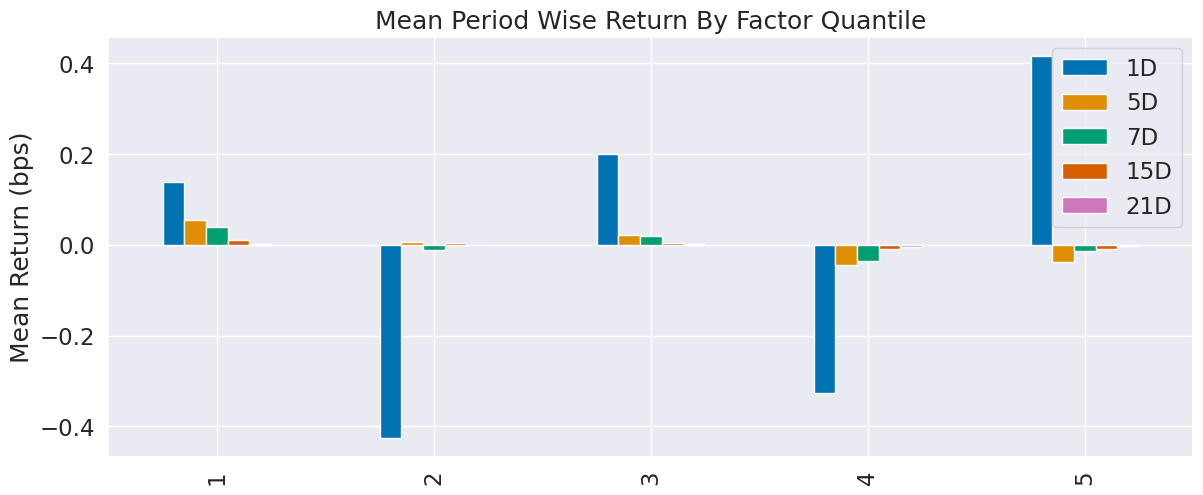

In [33]:
create_summary_tear_sheet(df)

## Combined-Model

### Factors

In [34]:
combined_factors=factor_data["Combined_Factor"]

### Summary Tear Sheet

In [35]:
df=get_clean_factor_and_forward_returns(
    factor=combined_factors,
    prices=trade_prices,
    quantiles=quantiles,
    periods=periods
)

Dropped 0.0% entries from factor data: 0.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!


Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.340408,0.012009,-0.009992,0.007273,146850,20.053558
2,-0.035590,0.015448,-0.005028,0.004167,146847,20.053148
3,-0.029160,0.018969,-0.002733,0.003936,144895,19.786587
4,-0.024157,0.022648,-0.000504,0.003836,146847,20.053148
5,-0.018127,0.191694,0.003946,0.005573,146850,20.053558


Returns Analysis


,1D,5D,7D,15D,21D
Ann. alpha,-0.005,-0.002,-0.001,-0.000,-0.000
beta,0.001,0.004,0.010,0.006,0.002
Mean Period Wise Return Top Quantile (bps),0.150,-0.052,-0.027,-0.011,-0.005
Mean Period Wise Return Bottom Quantile (bps),0.341,0.077,0.038,0.015,0.005
Mean Period Wise Spread (bps),-0.191,-0.129,-0.065,-0.026,-0.010


Information Analysis


,1D,5D,7D,15D,21D
IC Mean,-0.000,-0.003,-0.003,-0.004,-0.002
IC Std.,0.052,0.050,0.051,0.051,0.053
Risk-Adjusted IC,-0.006,-0.064,-0.061,-0.074,-0.047
t-stat(IC),-0.262,-2.818,-2.686,-3.283,-2.090
p-value(IC),0.793,0.005,0.007,0.001,0.037
IC Skew,0.023,0.006,-0.004,-0.011,0.005
IC Kurtosis,-0.087,-0.167,-0.209,0.050,-0.035


Turnover Analysis


,1D,5D,7D,15D,21D
Quantile 1 Mean Turnover,0.583,0.701,0.702,0.782,0.745
Quantile 2 Mean Turnover,0.741,0.775,0.777,0.792,0.787
Quantile 3 Mean Turnover,0.761,0.780,0.780,0.788,0.791
Quantile 4 Mean Turnover,0.740,0.770,0.768,0.791,0.783
Quantile 5 Mean Turnover,0.575,0.730,0.741,0.789,0.758


,1D,5D,7D,15D,21D
Mean Factor Rank Autocorrelation,0.409,0.138,0.131,-0.006,0.084


<Figure size 640x480 with 0 Axes>

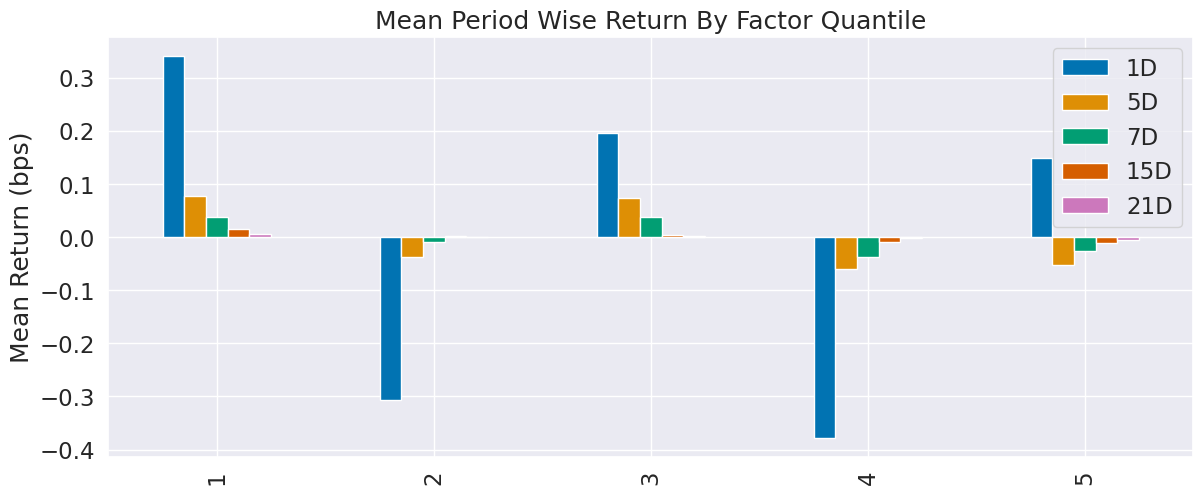

In [36]:
create_summary_tear_sheet(df)

# END